# Análisis Exploratorio de Datos (EDA)
## Telco Customer Churn

### Objetivo

Realizar un análisis exploratorio del conjunto de datos Telco Customer
Churn con el propósito de comprender su estructura, evaluar su calidad,
identificar las variables disponibles y detectar patrones preliminares
relacionados con el abandono de clientes.

Esta etapa no realizará transformaciones definitivas sobre los datos.
Los hallazgos obtenidos serán utilizados posteriormente para definir
el proceso ETL y la preparación necesaria para el modelamiento.

# 1. Configuración e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carga del dataset

In [2]:
import os

ruta_train = "../data/split/telco_train.csv"

df = pd.read_csv(ruta_train)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No


# 3. Exploración inicial

In [3]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5629,6308-CQRBU,Female,0,Yes,No,71,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,109.25,7707.7,No
5630,2842-JTCCU,Male,0,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),46.05,80.35,Yes
5631,6402-ZFPPI,Female,1,No,No,25,Yes,Yes,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,102.80,2660.2,Yes
5632,3594-BDSOA,Female,0,Yes,No,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.40,482.8,No
5633,6490-FGZAT,Male,0,No,No,6,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.65,109.3,No


In [4]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4820,2999-AANRQ,Female,0,No,No,21,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),71.05,1524.85,No
3186,8746-BFOAJ,Male,1,No,No,21,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Bank transfer (automatic),20.50,429.55,No
80,6333-YDVLT,Male,0,No,No,65,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),110.00,7138.65,No
1495,2195-ZRVAX,Female,0,Yes,No,47,Yes,No,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,85.30,4045.65,Yes
5121,0042-RLHYP,Female,0,Yes,Yes,69,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.70,1396.9,No


# 4. Estructura y dimensiones del dataset

In [5]:
print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 5634
Cantidad de columnas: 21


In [6]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

# 5. Tipos de datos

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  Paymen

TotalCharges esta guardado en el dataset como str, pero conceptualmente deberia ser un dato númerico

# 6. Calidad de los datos

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print("Valores vacíos por columna:")
print((df.astype(str).apply(lambda x: x.str.strip() == "")).sum())

Valores vacíos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
Churn               0
dtype: int64


*No hay variables con datos nulos pero TotalCharges presenta 8 registros vacíos representados como espacios en blanco. Estos registros corresponden a clientes con tenure = 0, por lo que deberán ser tratados durante la etapa de preparación de datos antes del modelamiento.

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [13]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1489
TotalCharges        5276
customerID          5634
dtype: int64

Esto nos ayuda a detectar cosas como:

customerID → casi todos únicos

Churn → 2

Contract → 3

In [12]:
variables_categoricas = df.select_dtypes(include="str").columns

variables_categoricas

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [15]:
for columna in variables_categoricas:
    print(f"\n--- {columna} ---")
    print(df[columna].value_counts(dropna=False))


--- customerID ---
customerID
4950-BDEUX    1
7993-NQLJE    1
7321-ZNSLA    1
4922-CVPDX    1
2903-YYTBW    1
             ..
6308-CQRBU    1
2842-JTCCU    1
6402-ZFPPI    1
3594-BDSOA    1
6490-FGZAT    1
Name: count, Length: 5634, dtype: int64

--- gender ---
gender
Male      2833
Female    2801
Name: count, dtype: int64

--- Partner ---
Partner
No     2905
Yes    2729
Name: count, dtype: int64

--- Dependents ---
Dependents
No     3955
Yes    1679
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    5075
No      559
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No                  2685
Yes                 2390
No phone service     559
Name: count, dtype: int64

--- InternetService ---
InternetService
Fiber optic    2483
DSL            1937
No             1214
Name: count, dtype: int64

--- OnlineSecurity ---
OnlineSecurity
No                     2797
Yes                    1623
No internet service    1214
Name: count, dtype: int64

--- OnlineBackup -

In [16]:
variables_numericas = df.select_dtypes(include=np.number).columns

variables_numericas

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [17]:
df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5634.0,0.163294,0.369667,0.0,0.0000,0.0,0.0,1.00
tenure,5634.0,32.485091,24.568744,0.0,9.0000,29.0,55.0,72.00
MonthlyCharges,5634.0,64.929961,30.138105,18.4,35.6625,70.5,90.0,118.75


### Hallazgo

La variable `TotalCharges` se encuentra almacenada como texto (`str`), 
aunque representa un monto monetario acumulado y debería tratarse como 
variable numérica.

Además, se identificaron 8 registros con espacios en blanco. Estos registros 
corresponden a clientes con `tenure = 0`.

### Acción para ETL

- Convertir los espacios en blanco a valores faltantes.
- Convertir `TotalCharges` a tipo numérico.
- Tratar los valores faltantes de forma reproducible dentro de la pipeline.

# 7. Variable objetivo

In [18]:
df["Churn"].value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

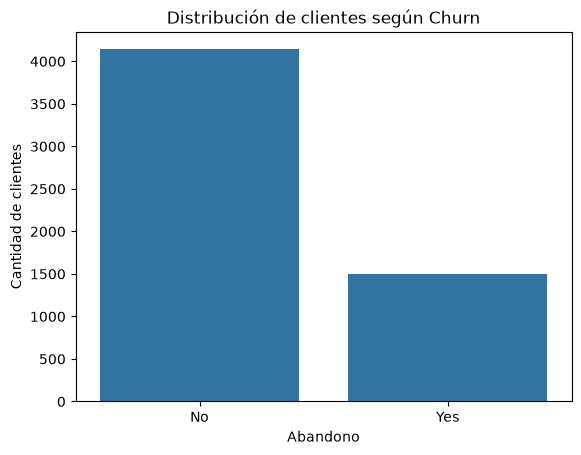

In [19]:
sns.countplot(data=df, x="Churn")

plt.title("Distribución de clientes según Churn")
plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")

plt.show()

## Nuestro primer KPI de negocio

In [20]:
churn_rate = (df["Churn"] == "Yes").mean() * 100

print(f"Tasa de abandono: {churn_rate:.2f}%")

Tasa de abandono: 26.54%


¿Qué variables parecen estar relacionadas con el abandono y cuáles podrían ser relevantes para el modelo?

In [21]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.253385,42.746615
One year,88.917306,11.082694
Two year,97.130243,2.869757


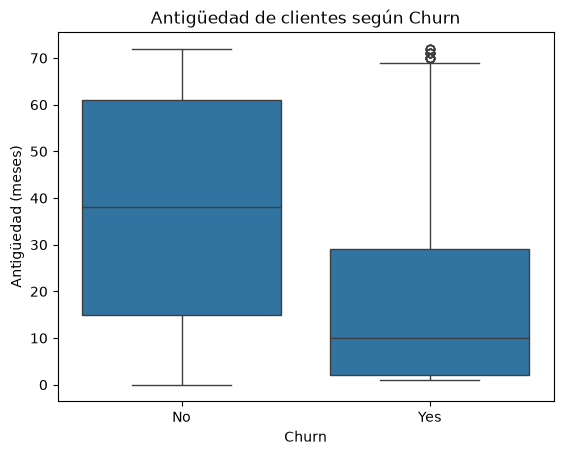

In [22]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Antigüedad de clientes según Churn")
plt.xlabel("Churn")
plt.ylabel("Antigüedad (meses)")

plt.show()

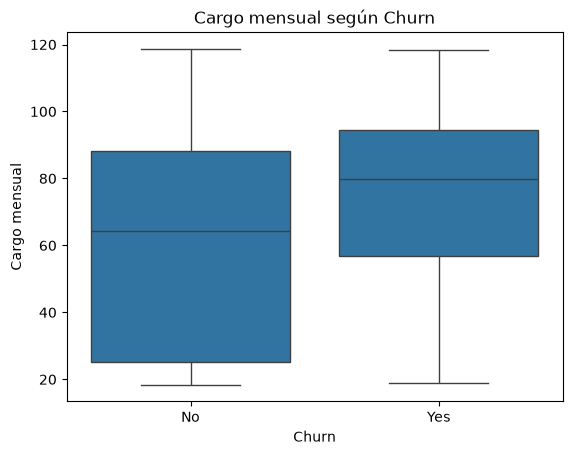

In [23]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Cargo mensual según Churn")
plt.xlabel("Churn")
plt.ylabel("Cargo mensual")

plt.show()

In [24]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.311306,18.688694
Fiber optic,57.913814,42.086186
No,92.751236,7.248764


In [4]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.246121,41.753879
No internet service,92.751236,7.248764
Yes,84.839297,15.160703


In [10]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.842444,16.157556
Credit card (automatic),85.078318,14.921682
Electronic check,54.257007,45.742993
Mailed check,80.715397,19.284603


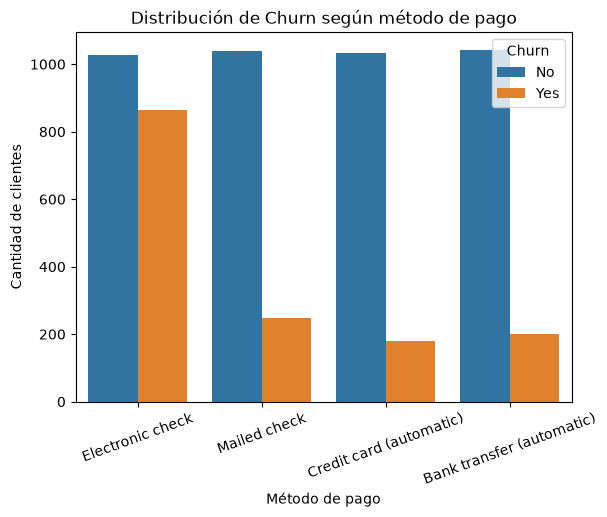

In [11]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Distribución de Churn según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=20)
plt.show()

# 8. Conclusiones del EDA

El análisis exploratorio permitió identificar los principales elementos que
deberán considerarse durante la preparación de los datos.

Los principales hallazgos fueron:

- `TotalCharges` está almacenada como texto y contiene 8 registros vacíos.
- `customerID` corresponde a un identificador único y no aporta información
  predictiva directa, por lo que no será utilizado como variable predictora.
- La variable objetivo `Churn` presenta dos categorías: `Yes` y `No`.
- La tasa de abandono observada en Train es de aproximadamente 26,54%.
- Existe una diferencia importante en la tasa de abandono según el tipo de
  contrato.
- Los clientes con contrato mensual presentan una tasa de abandono superior
  a los clientes con contratos de uno o dos años.
- Se observan diferencias en el abandono según la antigüedad (`tenure`),
  el cargo mensual y el tipo de servicio de Internet.
- Las variables categóricas deberán ser transformadas para poder ser utilizadas
  por los modelos de Machine Learning.
- Las variables numéricas deberán ser preparadas y escaladas para los algoritmos
  que sean sensibles a la escala.

Estos hallazgos serán utilizados como base para definir la pipeline de
preprocesamiento y transformación de datos.